# ReturnLoop — Week 2
## Data Collection, Cleaning & Preprocessing

**Project:** ReturnLoop: Data-Driven Reverse Logistics and E-Commerce Returns Analysis

**Scope:** This notebook covers only Week 2 requirements: data inspection, cleaning, validation, outlier assessment, categorical encoding and numerical standardization.

## 1. Import Libraries

In [46]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
from sklearn.preprocessing import StandardScaler, OneHotEncoder

pd.set_option("display.max_columns", None)
pd.set_option("display.width", 120)


## 2. Load Dataset

In [47]:
df = pd.read_excel(r"returns_sustainability_dataset.xlsx")

print(f"Rows: {df.shape[0]}")
print(f"Columns: {df.shape[1]}")
print("\nColumn names:")
print(list(df.columns))

print("\nInterpretation:")
print(f"1. The dataset contains {df.shape[0]:,} records and {df.shape[1]} variables.")

Rows: 5000
Columns: 23

Column names:
['Order_ID', 'Product_ID', 'User_ID', 'Order_Date', 'Product_Category', 'Product_Price', 'Order_Quantity', 'Discount_Applied', 'Shipping_Method', 'Payment_Method', 'User_Age', 'User_Gender', 'User_Location', 'Return_Status', 'Return_Reason', 'Days_to_Return', 'Order_Value', 'Return_Cost', 'Profit_Loss', 'CO2_Emissions', 'Packaging_Waste', 'CO2_Saved', 'Waste_Avoided']

Interpretation:
1. The dataset contains 5,000 records and 23 variables.


## 3. Initial Dataset Inspection

In [48]:
print("First 5 records:")
display(df.head())

print("\nDataset information:")
df.info()

print("\nNumerical summary:")
display(df.describe().T)


First 5 records:


,Order_ID,Product_ID,User_ID,Order_Date,Product_Category,Product_Price,Order_Quantity,Discount_Applied,Shipping_Method,Payment_Method,User_Age,User_Gender,User_Location,Return_Status,Return_Reason,Days_to_Return,Order_Value,Return_Cost,Profit_Loss,CO2_Emissions,Packaging_Waste,CO2_Saved,Waste_Avoided
0,ORD00000,PROD0169,USER0195,2022-01-14,Clothing,1720.71,2,30.46,Next-Day,Wallet,57,Female,City27,Not Returned,No Return,0,2393.163468,0,2393.163468,2.0,0.4,2.0,0.4
1,ORD00001,PROD0318,USER1469,2022-01-03,Toys,744.06,5,29.62,Next-Day,Wallet,55,Female,City5,Returned,Size Issue,12,2618.347140,200,2418.347140,2.0,1.0,0.0,0.0
2,ORD00002,PROD0427,USER1812,2025-03-16,Clothing,983.68,5,47.80,Express,Wallet,37,Female,City11,Not Returned,No Return,0,2567.404800,0,2567.404800,1.5,1.0,1.5,1.0
3,ORD00003,PROD0323,USER1274,2024-11-06,Books,1855.65,2,2.90,Express,COD,47,Female,City78,Not Returned,No Return,0,3603.672300,0,3603.672300,1.5,0.4,1.5,0.4
4,ORD00004,PROD0325,USER0551,2023-06-07,Home Appliances,1770.97,5,44.42,Express,COD,35,Female,City23,Returned,Size Issue,11,4921.525630,200,4721.525630,1.5,1.0,0.0,0.0



Dataset information:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5000 entries, 0 to 4999
Data columns (total 23 columns):
 #   Column            Non-Null Count  Dtype         
---  ------            --------------  -----         
 0   Order_ID          5000 non-null   object        
 1   Product_ID        5000 non-null   object        
 2   User_ID           5000 non-null   object        
 3   Order_Date        5000 non-null   datetime64[ns]
 4   Product_Category  5000 non-null   object        
 5   Product_Price     5000 non-null   float64       
 6   Order_Quantity    5000 non-null   int64         
 7   Discount_Applied  5000 non-null   float64       
 8   Shipping_Method   5000 non-null   object        
 9   Payment_Method    5000 non-null   object        
 10  User_Age          5000 non-null   int64         
 11  User_Gender       5000 non-null   object        
 12  User_Location     5000 non-null   object        
 13  Return_Status     5000 non-null   object        
 14  Re

,count,mean,min,25%,50%,75%,max,std
Order_Date,5000,2023-11-06 02:53:39.840000,2022-01-01 00:00:00,2022-12-03 18:00:00,2023-11-12 00:00:00,2024-10-17 00:00:00,2025-09-03 00:00:00,NaN
Product_Price,5000.0,1054.29474,100.09,580.9375,1044.85,1530.835,1999.8,548.560406
Order_Quantity,5000.0,2.9976,1.0,2.0,3.0,4.0,5.0,1.400709
Discount_Applied,5000.0,25.011476,0.0,12.8275,25.02,37.38,50.0,14.430681
User_Age,5000.0,41.5518,18.0,30.0,42.0,54.0,65.0,13.890195
Days_to_Return,5000.0,9.2042,0.0,0.0,0.0,12.0,60.0,16.753156
Order_Value,5000.0,2366.996469,52.165727,928.078449,1864.584053,3382.309799,9827.0172,1834.851991
Return_Cost,5000.0,58.0,0.0,0.0,0.0,200.0,200.0,90.761487
Profit_Loss,5000.0,2308.996469,-147.834273,863.90513,1808.077845,3345.67586,9827.0172,1838.461511
CO2_Emissions,5000.0,1.5001,1.0,1.0,1.5,2.0,2.0,0.410346


In [49]:
# Classify columns for the preprocessing workflow
identifier_cols = ["Order_ID", "Product_ID", "User_ID"]

date_cols = ["Order_Date"]

categorical_cols = [
    "Product_Category",
    "Shipping_Method",
    "Payment_Method",
    "User_Gender",
    "User_Location",
    "Return_Status",
    "Return_Reason"
]

numerical_cols = [
    "Product_Price",
    "Order_Quantity",
    "Discount_Applied",
    "User_Age",
    "Days_to_Return",
    "Order_Value",
    "Return_Cost",
    "Profit_Loss",
    "CO2_Emissions",
    "Packaging_Waste",
    "CO2_Saved",
    "Waste_Avoided"
]

print("Identifier columns:", identifier_cols)
print("Date columns:", date_cols)
print("Categorical columns:", categorical_cols)
print("Numerical columns:", numerical_cols)

print("\nInterpretation:")
print("1. The variables are separated by role so that each preprocessing method is applied only where appropriate.")
print("2. Identifier columns are retained but are not used for numerical scaling or categorical encoding.")


Identifier columns: ['Order_ID', 'Product_ID', 'User_ID']
Date columns: ['Order_Date']
Categorical columns: ['Product_Category', 'Shipping_Method', 'Payment_Method', 'User_Gender', 'User_Location', 'Return_Status', 'Return_Reason']
Numerical columns: ['Product_Price', 'Order_Quantity', 'Discount_Applied', 'User_Age', 'Days_to_Return', 'Order_Value', 'Return_Cost', 'Profit_Loss', 'CO2_Emissions', 'Packaging_Waste', 'CO2_Saved', 'Waste_Avoided']

Interpretation:
1. The variables are separated by role so that each preprocessing method is applied only where appropriate.
2. Identifier columns are retained but are not used for numerical scaling or categorical encoding.


## 4. Missing Value Assessment

In [50]:
missing_count = df.isnull().sum()
missing_pct = (missing_count / len(df) * 100).round(2)

missing_summary = pd.DataFrame({
    "Missing_Count": missing_count,
    "Missing_Percentage": missing_pct
})

display(missing_summary)

total_missing = int(missing_count.sum())

if total_missing == 0:
    print("Result: No missing values were found.")
    print("Action: No imputation was required.")
else:
    print(f"Result: {total_missing} missing cells were found.")
    print("Action: Missing values will be handled according to variable type.")

    for col in missing_count[missing_count > 0].index:
        if col in numerical_cols:
            df[col] = df[col].fillna(df[col].median())
        else:
            df[col] = df[col].fillna(df[col].mode()[0])

print("\nInterpretation:")
print("1. Missing-value treatment is performed only when missing observations are actually present.")
print("2. This prevents unnecessary imputation from changing valid information in the dataset.")


,Missing_Count,Missing_Percentage
Order_ID,0,0.0
Product_ID,0,0.0
User_ID,0,0.0
Order_Date,0,0.0
Product_Category,0,0.0
Product_Price,0,0.0
Order_Quantity,0,0.0
Discount_Applied,0,0.0
Shipping_Method,0,0.0
Payment_Method,0,0.0


Result: No missing values were found.
Action: No imputation was required.

Interpretation:
1. Missing-value treatment is performed only when missing observations are actually present.
2. This prevents unnecessary imputation from changing valid information in the dataset.


## 5. Duplicate Detection and Handling

In [51]:
duplicates_before = int(df.duplicated().sum())

print(f"Duplicate rows found: {duplicates_before}")

if duplicates_before > 0:
    df = df.drop_duplicates().reset_index(drop=True)
    print(f"Action: {duplicates_before} duplicate rows removed.")
else:
    print("Action: No duplicate rows were removed.")

print(f"Rows after duplicate check: {len(df)}")

print("\nInterpretation:")
print("1. Duplicate records can cause observations to be counted more than once.")
print("2. Only exact duplicate rows are removed; valid repeated business transactions are retained.")


Duplicate rows found: 0
Action: No duplicate rows were removed.
Rows after duplicate check: 5000

Interpretation:
1. Duplicate records can cause observations to be counted more than once.
2. Only exact duplicate rows are removed; valid repeated business transactions are retained.


## 6. Data Type Validation and Correction

In [52]:
print("Data types before correction:")
display(df.dtypes.to_frame("Data_Type"))

date_missing_before = int(df["Order_Date"].isna().sum())

df["Order_Date"] = pd.to_datetime(df["Order_Date"], errors="coerce")

date_missing_after = int(df["Order_Date"].isna().sum())

print("\nOrder_Date conversion:")
print(f"Missing dates before conversion: {date_missing_before}")
print(f"Missing dates after conversion:  {date_missing_after}")

print("\nData types after correction:")
display(df.dtypes.to_frame("Data_Type"))

if date_missing_after > date_missing_before:
    print("Warning: Date conversion created new missing values. The source format should be reviewed.")
else:
    print("Result: Order_Date was successfully converted without creating new missing values.")

print("\nInterpretation:")
print("1. Order_Date is converted to datetime so that future time-based logistics analysis can be performed correctly.")
print("2. No other data type is changed unless the dataset provides evidence that a correction is required.")


Data types before correction:


,Data_Type
Order_ID,object
Product_ID,object
User_ID,object
Order_Date,datetime64[ns]
Product_Category,object
Product_Price,float64
Order_Quantity,int64
Discount_Applied,float64
Shipping_Method,object
Payment_Method,object



Order_Date conversion:
Missing dates before conversion: 0
Missing dates after conversion:  0

Data types after correction:


,Data_Type
Order_ID,object
Product_ID,object
User_ID,object
Order_Date,datetime64[ns]
Product_Category,object
Product_Price,float64
Order_Quantity,int64
Discount_Applied,float64
Shipping_Method,object
Payment_Method,object


Result: Order_Date was successfully converted without creating new missing values.

Interpretation:
1. Order_Date is converted to datetime so that future time-based logistics analysis can be performed correctly.
2. No other data type is changed unless the dataset provides evidence that a correction is required.


## 7. Categorical Data Validation

In [53]:
print("Unique values in categorical columns:\n")

categorical_issues = []

for col in categorical_cols:
    values = df[col].dropna().astype(str)
    whitespace_issues = int((values != values.str.strip()).sum())
    blank_values = int((values.str.strip() == "").sum())

    categorical_issues.append([
        col,
        df[col].nunique(),
        whitespace_issues,
        blank_values
    ])

categorical_summary = pd.DataFrame(
    categorical_issues,
    columns=["Column", "Unique_Values", "Whitespace_Issues", "Blank_Values"]
)

display(categorical_summary)

total_cat_issues = int(
    categorical_summary["Whitespace_Issues"].sum()
    + categorical_summary["Blank_Values"].sum()
)

if total_cat_issues == 0:
    print("Result: No whitespace or blank-value issues were detected.")
    print("Action: No categorical relabelling was required.")
else:
    print(f"Result: {total_cat_issues} categorical formatting issues were detected.")
    print("Action: Review affected categories before applying corrections.")

print("\nInterpretation:")
print("1. Consistent category labels are necessary to prevent the same category from being treated as multiple groups.")
print("2. No category is changed unless an actual formatting inconsistency is detected.")


Unique values in categorical columns:



,Column,Unique_Values,Whitespace_Issues,Blank_Values
0,Product_Category,5,0,0
1,Shipping_Method,3,0,0
2,Payment_Method,4,0,0
3,User_Gender,2,0,0
4,User_Location,100,0,0
5,Return_Status,2,0,0
6,Return_Reason,5,0,0


Result: No whitespace or blank-value issues were detected.
Action: No categorical relabelling was required.

Interpretation:
1. Consistent category labels are necessary to prevent the same category from being treated as multiple groups.
2. No category is changed unless an actual formatting inconsistency is detected.


## 8. Logical Consistency Checks

In [54]:
def count_violations(rule_name, mask):
    count = int(mask.sum())
    print(f"{rule_name}: {count}")
    return count

print("Logical consistency violations:\n")

violations = {}

violations["Returned orders with 'No Return' reason"] = count_violations(
    "Returned orders with 'No Return' reason",
    (df["Return_Status"] == "Returned") &
    (df["Return_Reason"] == "No Return")
)

violations["Not-returned orders with a return reason"] = count_violations(
    "Not-returned orders with a return reason",
    (df["Return_Status"] == "Not Returned") &
    (df["Return_Reason"] != "No Return")
)

violations["Returned orders with Days_to_Return <= 0"] = count_violations(
    "Returned orders with Days_to_Return <= 0",
    (df["Return_Status"] == "Returned") &
    (df["Days_to_Return"] <= 0)
)

violations["Not-returned orders with Days_to_Return != 0"] = count_violations(
    "Not-returned orders with Days_to_Return != 0",
    (df["Return_Status"] == "Not Returned") &
    (df["Days_to_Return"] != 0)
)

violations["Returned orders with Return_Cost <= 0"] = count_violations(
    "Returned orders with Return_Cost <= 0",
    (df["Return_Status"] == "Returned") &
    (df["Return_Cost"] <= 0)
)

violations["Not-returned orders with Return_Cost != 0"] = count_violations(
    "Not-returned orders with Return_Cost != 0",
    (df["Return_Status"] == "Not Returned") &
    (df["Return_Cost"] != 0)
)

violations["Product_Price <= 0"] = count_violations(
    "Product_Price <= 0",
    df["Product_Price"] <= 0
)

violations["Order_Quantity <= 0"] = count_violations(
    "Order_Quantity <= 0",
    df["Order_Quantity"] <= 0
)

violations["Discount outside 0-100"] = count_violations(
    "Discount outside 0-100",
    (df["Discount_Applied"] < 0) |
    (df["Discount_Applied"] > 100)
)

violations["User_Age outside 18-100"] = count_violations(
    "User_Age outside 18-100",
    (df["User_Age"] < 18) |
    (df["User_Age"] > 100)
)

violations["Negative environmental measures"] = count_violations(
    "Negative environmental measures",
    (df["CO2_Emissions"] < 0) |
    (df["Packaging_Waste"] < 0) |
    (df["CO2_Saved"] < 0) |
    (df["Waste_Avoided"] < 0)
)

violations["Recovered amount exceeds generated amount"] = count_violations(
    "Recovered amount exceeds generated amount",
    (df["CO2_Saved"] > df["CO2_Emissions"]) |
    (df["Waste_Avoided"] > df["Packaging_Waste"])
)

total_violations = sum(violations.values())

print(f"\nTotal violations: {total_violations}")

if total_violations == 0:
    print("Action: No logical corrections were required.")
else:
    print("Action: Violations require inspection before any records are changed.")

print("\nInterpretation:")
print("1. Business-rule checks confirm whether related logistics fields agree with each other.")
print("2. Records are not automatically deleted because an apparent exception may represent a valid business case.")


Logical consistency violations:

Returned orders with 'No Return' reason: 0
Not-returned orders with a return reason: 0
Returned orders with Days_to_Return <= 0: 0
Not-returned orders with Days_to_Return != 0: 0
Returned orders with Return_Cost <= 0: 0
Not-returned orders with Return_Cost != 0: 0
Product_Price <= 0: 0
Order_Quantity <= 0: 0
Discount outside 0-100: 0
User_Age outside 18-100: 0
Negative environmental measures: 0
Recovered amount exceeds generated amount: 0

Total violations: 0
Action: No logical corrections were required.

Interpretation:
1. Business-rule checks confirm whether related logistics fields agree with each other.
2. Records are not automatically deleted because an apparent exception may represent a valid business case.


## 9. Outlier Detection Using IQR

In [55]:
outlier_cols = [
    "Product_Price",
    "Order_Quantity",
    "Discount_Applied",
    "User_Age",
    "Days_to_Return",
    "Order_Value",
    "Return_Cost",
    "Profit_Loss",
    "CO2_Emissions",
    "Packaging_Waste",
    "CO2_Saved",
    "Waste_Avoided"
]

outlier_results = []

for col in outlier_cols:
    q1 = df[col].quantile(0.25)
    q3 = df[col].quantile(0.75)
    iqr = q3 - q1
    lower = q1 - 1.5 * iqr
    upper = q3 + 1.5 * iqr

    count = int(((df[col] < lower) | (df[col] > upper)).sum())

    outlier_results.append([
        col, q1, q3, iqr, lower, upper, count
    ])

outlier_summary = pd.DataFrame(
    outlier_results,
    columns=[
        "Variable", "Q1", "Q3", "IQR",
        "Lower_Bound", "Upper_Bound", "Potential_Outliers"
    ]
)

display(outlier_summary.round(2))

total_potential_outliers = int(outlier_summary["Potential_Outliers"].sum())

print(f"Total potential outlier observations across variables: {total_potential_outliers}")
print("Treatment decision: Potential outliers are retained unless they are confirmed to be invalid values.")

print("\nInterpretation:")
print("1. IQR identifies unusually high or low observations but does not prove that they are errors.")
print("2. Legitimate high-value orders or longer return periods should therefore be retained for later analysis.")


,Variable,Q1,Q3,IQR,Lower_Bound,Upper_Bound,Potential_Outliers
0,Product_Price,580.94,1530.84,949.90,-843.91,2955.68,0
1,Order_Quantity,2.00,4.00,2.00,-1.00,7.00,0
2,Discount_Applied,12.83,37.38,24.55,-24.00,74.21,0
3,User_Age,30.00,54.00,24.00,-6.00,90.00,0
4,Days_to_Return,0.00,12.00,12.00,-18.00,30.00,741
5,Order_Value,928.08,3382.31,2454.23,-2753.27,7063.66,108
6,Return_Cost,0.00,200.00,200.00,-300.00,500.00,0
7,Profit_Loss,863.91,3345.68,2481.77,-2858.75,7068.33,106
8,CO2_Emissions,1.00,2.00,1.00,-0.50,3.50,0
9,Packaging_Waste,0.40,0.80,0.40,-0.20,1.40,0


Total potential outlier observations across variables: 955
Treatment decision: Potential outliers are retained unless they are confirmed to be invalid values.

Interpretation:
1. IQR identifies unusually high or low observations but does not prove that they are errors.
2. Legitimate high-value orders or longer return periods should therefore be retained for later analysis.


### 9.1 Outlier Visualization

Boxplots are used only to visually support the IQR-based outlier assessment. The purpose of this visual is data-quality checking, not business interpretation.


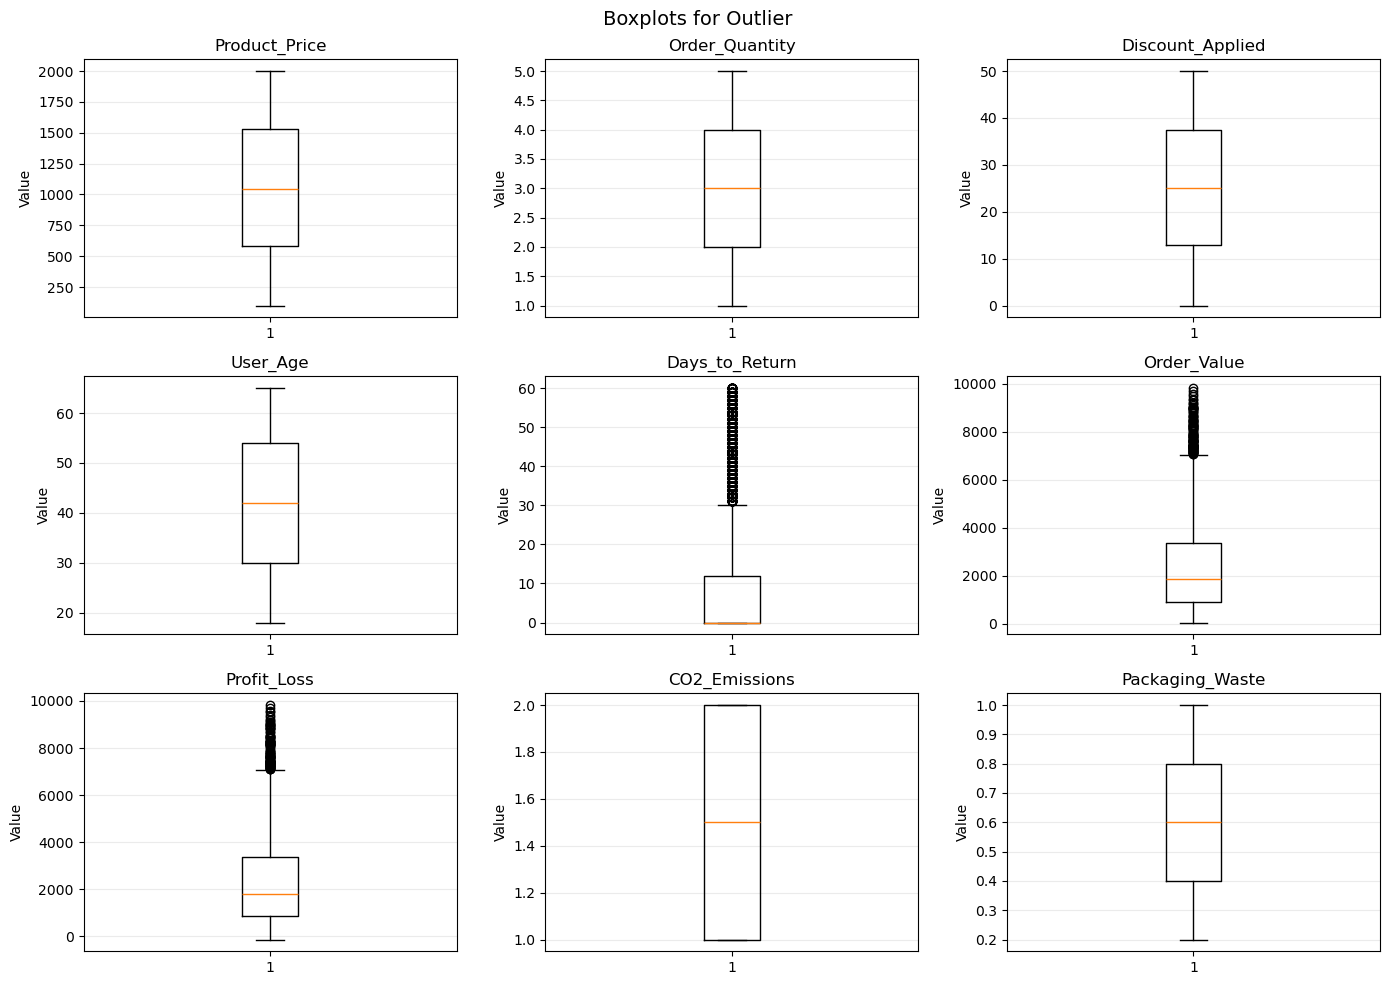

Interpretation:
1. The boxplots provide a visual check of the potential outliers identified using the IQR method.
2. Extreme observations are not removed automatically; they are retained unless they are confirmed to be invalid.


In [56]:
# Visual check of potential outliers
plot_cols = [
    "Product_Price",
    "Order_Quantity",
    "Discount_Applied",
    "User_Age",
    "Days_to_Return",
    "Order_Value",
    "Profit_Loss",
    "CO2_Emissions",
    "Packaging_Waste"
]

fig, axes = plt.subplots(3, 3, figsize=(14, 10))
axes = axes.flatten()

for ax, col in zip(axes, plot_cols):
    ax.boxplot(df[col].dropna(), vert=True)
    ax.set_title(col)
    ax.set_ylabel("Value")
    ax.grid(axis="y", alpha=0.25)

plt.suptitle(" Boxplots for Outlier", fontsize=14)
plt.tight_layout()
plt.show()

print("Interpretation:")
print("1. The boxplots provide a visual check of the potential outliers identified using the IQR method.")
print("2. Extreme observations are not removed automatically; they are retained unless they are confirmed to be invalid.")


## 10. Categorical Encoding for the Processed Dataset

In [57]:
# Keep the cleaned 23-column dataset unchanged.
# Create a separate encoded version for future modelling.

encode_cols = [
    "Product_Category",
    "Shipping_Method",
    "Payment_Method",
    "User_Gender",
    "User_Location"
]

encoder = OneHotEncoder(
    handle_unknown="ignore",
    sparse_output=False
)

encoded_array = encoder.fit_transform(df[encode_cols])

encoded_df = pd.DataFrame(
    encoded_array,
    columns=encoder.get_feature_names_out(encode_cols),
    index=df.index
)

df_encoded = pd.concat(
    [
        df.drop(columns=encode_cols),
        encoded_df
    ],
    axis=1
)

print(f"Original cleaned columns: {df.shape[1]}")
print(f"Columns after one-hot encoding: {df_encoded.shape[1]}")

print("\nInterpretation:")
print("1. Categorical predictors are converted into numerical indicator variables for future machine-learning use.")
print("2. The original cleaned dataset remains unchanged and retains all 23 original columns.")


Original cleaned columns: 23
Columns after one-hot encoding: 132

Interpretation:
1. Categorical predictors are converted into numerical indicator variables for future machine-learning use.
2. The original cleaned dataset remains unchanged and retains all 23 original columns.


## 11. Numerical Standardization

In [58]:
scale_cols = [
    "Product_Price",
    "Order_Quantity",
    "Discount_Applied",
    "User_Age",
    "Days_to_Return",
    "Order_Value",
    "Return_Cost",
    "Profit_Loss",
    "CO2_Emissions",
    "Packaging_Waste",
    "CO2_Saved",
    "Waste_Avoided"
]

scaler = StandardScaler()

df_processed = df_encoded.copy()

df_processed[scale_cols] = scaler.fit_transform(
    df_processed[scale_cols]
)

print("Standardization completed for numerical variables.")
display(df_processed[scale_cols].describe().loc[["mean", "std"]].round(3))

print("\nInterpretation:")
print("1. Numerical variables are standardized to comparable scales for future scale-sensitive modelling.")
print("2. Identifier and categorical variables are not scaled.")


Standardization completed for numerical variables.


,Product_Price,Order_Quantity,Discount_Applied,User_Age,Days_to_Return,Order_Value,Return_Cost,Profit_Loss,CO2_Emissions,Packaging_Waste,CO2_Saved,Waste_Avoided
mean,0.0,0.0,-0.0,-0.0,0.0,0.0,0.0,0.0,0.0,-0.0,0.0,0.0
std,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0



Interpretation:
1. Numerical variables are standardized to comparable scales for future scale-sensitive modelling.
2. Identifier and categorical variables are not scaled.


## 12. Final Validation

In [59]:
print("FINAL VALIDATION")
print("-" * 50)

print(f"Cleaned dataset shape: {df.shape}")
print(f"Processed dataset shape: {df_processed.shape}")
print(f"Missing values in cleaned dataset: {int(df.isnull().sum().sum())}")
print(f"Duplicate rows in cleaned dataset: {int(df.duplicated().sum())}")
print(f"Order_Date dtype: {df['Order_Date'].dtype}")

print("\nFinal interpretation:")
print("1. The cleaned dataset preserves the original variables while applying only justified data-quality corrections.")
print("2. The processed dataset is additionally encoded and standardized for use in later modelling stages.")


FINAL VALIDATION
--------------------------------------------------
Cleaned dataset shape: (5000, 23)
Processed dataset shape: (5000, 132)
Missing values in cleaned dataset: 0
Duplicate rows in cleaned dataset: 0
Order_Date dtype: datetime64[ns]

Final interpretation:
1. The cleaned dataset preserves the original variables while applying only justified data-quality corrections.
2. The processed dataset is additionally encoded and standardized for use in later modelling stages.


## 13. Save the Datasets

In [60]:
# Save the cleaned dataset with the original 23-column structure.
# Save the cleaned dataset
CLEANED_FILE = "ReturnLoop_Week2_Cleaned_Dataset.csv"

df.to_csv(CLEANED_FILE, index=False)

print(f"Cleaned dataset saved as: {CLEANED_FILE}")

Cleaned dataset saved as: ReturnLoop_Week2_Cleaned_Dataset.csv


In [62]:
print("WEEK 2 PREPROCESSING SUMMARY")
print("-" * 40)

print(f"Original dataset: {df.shape[0]} rows × {df.shape[1]} columns")
print(f"Cleaned dataset: {df.shape[0]} rows × {df.shape[1]} columns")
print(f"Missing values: {df.isnull().sum().sum()}")
print(f"Duplicate rows: {df.duplicated().sum()}")
print(f"Date column type: {df['Order_Date'].dtype}")

print("\nInterpretation:")
print("1. The dataset has been checked and prepared for further logistics analysis.")
print("2. The cleaned dataset is ready for the next stage of the project.")

WEEK 2 PREPROCESSING SUMMARY
----------------------------------------
Original dataset: 5000 rows × 23 columns
Cleaned dataset: 5000 rows × 23 columns
Missing values: 0
Duplicate rows: 0
Date column type: datetime64[ns]

Interpretation:
1. The dataset has been checked and prepared for further logistics analysis.
2. The cleaned dataset is ready for the next stage of the project.
